# Loan Default Risk Analysis
## Notebook 04 — Statistical Analysis

Objective:
To validate EDA findings through formal statistical tests, quantify the
strength of relationships between key variables and default status, and
provide statistically grounded business recommendations for the mortgage
lending portfolio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('loan_final_cleanedd.csv')

## Section: Descriptive Statistics — Defaulters vs Non-Defaulters

In [2]:
desc = df.groupby('status')[['credit_score','debt_to_income_ratio',
                              'ltv','income','loan_amount',
                              'rate_of_interest']].agg(['mean','median','std']).round(2)

desc.index = ['No Default', 'Default']
desc

credit_score                debt_to_income_ratio               \
                   mean median     std                 mean median   std   
No Default       698.44  699.0  115.47                37.49   39.0  9.71   
Default          697.69  697.0  115.70                39.59   39.0  9.12   

              ltv                 income                  loan_amount  \
             mean median    std     mean  median      std        mean   
No Default  71.65  74.41  18.47  7096.43  5820.0  5389.09   335778.10   
Default     77.04  77.14  36.14  6162.36  4950.0  6735.63   315954.75   

                                rate_of_interest               
              median        std             mean median   std  
No Default  306500.0  172834.04             4.04   3.99  0.56  
Default     276500.0  210459.25             4.04   4.04  0.04

### Observation
Defaulters and non-defaulters show nearly identical mean credit scores (697.69 vs 698.44). DTI is slightly higher in defaulters (39.59 vs 37.49) and LTV is also higher (77.04 vs 71.65). Defaulters earn less on average (₹6,162 vs ₹7,096). Notably, interest rates are virtually the same for both groups (4.04% vs 3.99%).
### Insight
The most striking finding is the interest rate gap — at just 0.05%, the institution charged defaulters almost the same rate as safe borrowers. This means risk was not priced into the loans at origination. Among the financial metrics, repayment capacity (income and LTV) shows more separation between the two groups than credit score does — which shows less than 1 point difference despite being the most commonly used screening tool.


## Section: Hypothesis Testing

In [3]:

defaulters = df[df['status']==1]
non_defaulters = df[df['status']==0]

variables = ['credit_score', 'debt_to_income_ratio', 'ltv', 'income']

print(f"{'Variable':<25} {'Mean (Default)':<18} {'Mean (No Default)':<20} {'T-Stat':<12} {'P-Value':<12} {'Significant?'}")
print("-"*100)

for var in variables:
    t_stat, p_val = stats.ttest_ind(defaulters[var].dropna(),
                                     non_defaulters[var].dropna())
    mean_d = defaulters[var].mean().round(2)
    mean_nd = non_defaulters[var].mean().round(2)
    sig = "Yes ✓" if p_val < 0.05 else "No ✗"
    print(f"{var:<25} {mean_d:<18} {mean_nd:<20} {t_stat:<12.3f} {p_val:<12.5f} {sig}")

Variable                  Mean (Default)     Mean (No Default)    T-Stat       P-Value      Significant?
----------------------------------------------------------------------------------------------------
credit_score              697.69             698.44               -0.339       0.73456      No ✗
debt_to_income_ratio      39.59              37.49                11.423       0.00000      Yes ✓
ltv                       77.04              71.65                11.760       0.00000      Yes ✓
income                    6162.36            7096.43              -8.482       0.00000      Yes ✓


### Observation
Credit score is the only variable that is NOT statistically significant (p = 0.735). DTI, LTV, and income all show p = 0.000 — highly significant differences between defaulters and non-defaulters.
### Insight
A p-value of 0.735 means credit score differences between the two groups could easily be due to random chance — it proves nothing. LTV and DTI on the other hand are extremely unlikely to differ by chance, making them statistically valid screening variables unlike credit score.

## Section: Chi-Square Tests


In [4]:

from scipy.stats import chi2_contingency

cat_vars = ['region', 'loan_type', 'loan_purpose',
            'neg_ammortization', 'lump_sum_payment',
            'occupancy_type', 'ltv_risk_bucket', 'credit_score_bucket']

print(f"{'Variable':<30} {'Chi2 Stat':<15} {'P-Value':<15} {'Significant?'}")
print("-"*70)

for var in cat_vars:
    ct = pd.crosstab(df[var], df['status'])
    chi2, p, dof, expected = chi2_contingency(ct)
    sig = "Yes ✓" if p < 0.05 else "No ✗"
    print(f"{var:<30} {chi2:<15.3f} {p:<15.5f} {sig}")

Variable                       Chi2 Stat       P-Value         Significant?
----------------------------------------------------------------------
region                         29.609          0.00000         Yes ✓
loan_type                      136.965         0.00000         Yes ✓
loan_purpose                   42.847          0.00000         Yes ✓
neg_ammortization              363.064         0.00000         Yes ✓
lump_sum_payment               498.517         0.00000         Yes ✓
occupancy_type                 13.940          0.00094         Yes ✓
ltv_risk_bucket                451.937         0.00000         Yes ✓
credit_score_bucket            2.073           0.72233         No ✗


### Observation
All categorical variables are statistically significant except credit_score_bucket (p = 0.722). Lump sum payment (χ² = 498.5) and LTV risk bucket (χ² = 451.9) show the strongest associations with default. Negative amortisation (χ² = 363.1) and loan type (χ² = 137.0) also show strong associations.
### Insight
 Product features like lump sum payment and negative amortisation are far stronger predictors of default than any borrower characteristic. This suggests the type of loan product offered matters more than who the borrower is — a fundamental gap in how risk is currently being assessed.

## Section: Point Biserial Correlation

In [5]:


from scipy.stats import pointbiserialr

num_vars = ['credit_score', 'debt_to_income_ratio', 'ltv',
            'income', 'loan_amount', 'rate_of_interest']

print(f"{'Variable':<25} {'Correlation':<15} {'P-Value':<15} {'Significant?'}")
print("-"*65)

for var in num_vars:
    corr, p = pointbiserialr(df['status'], df[var].fillna(df[var].median()))
    sig = "Yes ✓" if p < 0.05 else "No ✗"
    print(f"{var:<25} {corr:<15.4f} {p:<15.5f} {sig}")

Variable                  Correlation     P-Value         Significant?
-----------------------------------------------------------------
credit_score              -0.0028         0.73456         No ✗
debt_to_income_ratio      0.0929          0.00000         Yes ✓
ltv                       0.0956          0.00000         Yes ✓
income                    -0.0691         0.00000         Yes ✓
loan_amount               -0.0462         0.00000         Yes ✓
rate_of_interest          0.0014          0.86352         No ✗


### Observation
Credit score has a correlation of -0.0028 with default — effectively zero and not significant (p = 0.735). LTV (0.0956) and DTI (0.0929) are the only variables with meaningful positive correlations. Income (-0.0691) and loan amount (-0.0462) show negative correlations. Rate of interest (0.0014) is also near zero and not significant (p = 0.864).
### Insight
Higher income and larger loan amounts are both associated with lower default — suggesting borrowers who qualify for bigger loans are relatively safer. Rate of interest being near zero confirms again that the institution did not price risk into loan rates. Only LTV and DTI move in the right direction as reliable risk signals.

# Feature importance visualization based on Point Biserial correlations

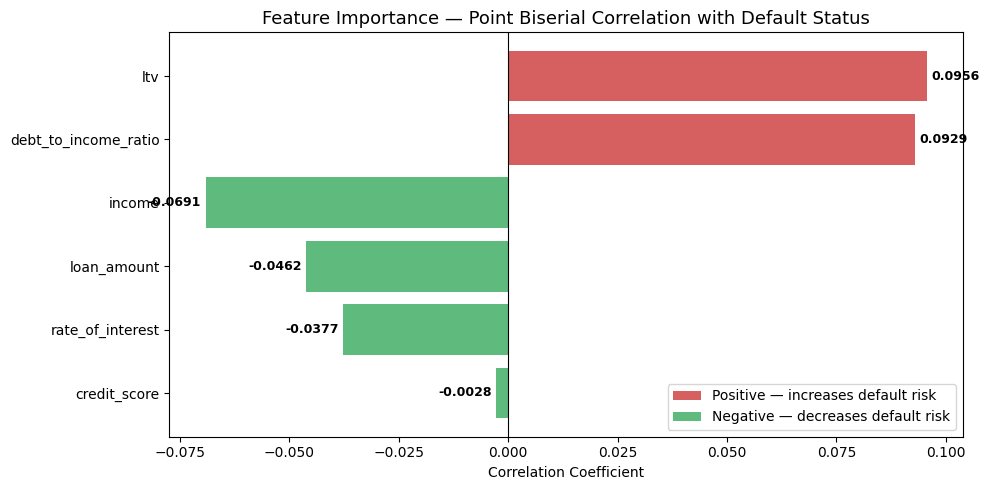

In [15]:
pb_data = {
    'Variable': ['ltv', 'debt_to_income_ratio', 'rate_of_interest',
                 'loan_amount', 'income', 'credit_score'],
    'Correlation': [0.0956, 0.0929, -0.0377, -0.0462, -0.0691, -0.0028]
}
pb_df = pd.DataFrame(pb_data).sort_values('Correlation', key=abs, ascending=True)

colors = ['#d65f5f' if x > 0 else '#5fba7d' for x in pb_df['Correlation']]

plt.figure(figsize=(10, 5))
bars = plt.barh(pb_df['Variable'], pb_df['Correlation'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)

# Value labels on each bar
for bar, val in zip(bars, pb_df['Correlation']):
    plt.text(val + (0.001 if val >= 0 else -0.001),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center',
             ha='left' if val >= 0 else 'right',
             fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d65f5f', label='Positive — increases default risk'),
                   Patch(facecolor='#5fba7d', label='Negative — decreases default risk')]
plt.legend(handles=legend_elements, loc='lower right')

plt.title('Feature Importance — Point Biserial Correlation with Default Status', fontsize=13)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

### Observation
LTV (0.0956) and DTI (0.0929) are the only variables with positive correlations — meaning they increase default risk as they rise. Income (-0.0691), loan amount (-0.0462), and rate of interest (-0.0377) all decrease default risk as they rise. Credit score (-0.0028) is virtually flat — the shortest bar on the chart.
### Insight
 LTV and DTI are the only variables that move in the same direction as default risk — making them the only valid numerical gates for screening. Credit score ranks last despite being the industry standard, confirming it should not be the primary filter in this portfolio's underwriting process.

## Section: Risk Quantification

###Default rate by LTV bucket with exposure

In [7]:

ltv_risk = df.groupby('ltv_risk_bucket').agg(
    total_loans=('status','count'),
    defaults=('status','sum'),
    total_exposure=('loan_amount','sum')
).assign(
    default_rate=lambda x: (x['defaults']/x['total_loans']*100).round(1),
    exposure_at_default=lambda x: x.apply(
        lambda r: df[(df['ltv_risk_bucket']==r.name) &
                    (df['status']==1)]['loan_amount'].sum(), axis=1)
)
ltv_risk.reset_index().style \
    .set_caption("LTV Risk Bucket — Default Rate & Exposure Analysis") \
    .format({'total_exposure': '₹{:,.0f}',
             'exposure_at_default': '₹{:,.0f}',
             'default_rate': '{:.1f}%'}).hide(axis='index')

ltv_risk_bucket,total_loans,defaults,total_exposure,default_rate,exposure_at_default
High,2713,555,"₹922,814,500",20.5%,"₹176,587,500"
Low,3931,1068,"₹1,130,241,500",27.2%,"₹238,952,000"
Moderate,5386,871,"₹1,834,139,000",16.2%,"₹280,121,500"
Very High,2970,1064,"₹1,078,945,000",35.8%,"₹428,506,000"


###Scenario: What if we cap LTV at 100%?

In [8]:
very_high = df[df['ltv_risk_bucket']=='Very High']
print(f"\nLoans with Very High LTV: {len(very_high)}")
print(f"Defaults in this segment: {very_high['status'].sum()}")
print(f"Current default rate: {df['status'].mean()*100:.2f}%")
revised_defaults = df['status'].sum() - very_high['status'].sum()
revised_total = len(df) - len(very_high)
print(f"Revised default rate (if LTV cap applied): {revised_defaults/revised_total*100:.2f}%")
print(f"EAD reduction: ₹{very_high[very_high['status']==1]['loan_amount'].sum():,.0f}")


Loans with Very High LTV: 2970
Defaults in this segment: 1064
Current default rate: 23.72%
Revised default rate (if LTV cap applied): 20.73%
EAD reduction: ₹428,506,000


### Observation
Very High LTV borrowers default at 35.8% — the highest of any bucket — with 1,064 defaults and ₹4,28,506,000 in exposure. Moderate LTV is the safest at 16.2% despite having the most loans (5,386). Low LTV defaults at 27.2% — higher than both High and Moderate LTV buckets.
### Insight
Capping Very High LTV would reduce the portfolio default rate from 23.72% to 20.73% and save ₹4,28,506,000 in exposure. However, the real surprise is Moderate LTV being the safest segment — meaning an LTV cap alone is not enough. DTI controls need to run alongside it to address the risk hiding in lower LTV segments.


## Section: DTI Threshold Analysis

In [9]:
thresholds = [35, 40, 43, 45, 50]

dti_results = []
for t in thresholds:
    above = df[df['debt_to_income_ratio'] > t]['status'].mean()*100
    below = df[df['debt_to_income_ratio'] <= t]['status'].mean()*100
    dti_results.append({
        'DTI Threshold': t,
        'Default Rate Above (%)': round(above, 1),
        'Default Rate Below (%)': round(below, 1),
        'Difference': round(above-below, 1)
    })

dti_df = pd.DataFrame(dti_results)
dti_df.style \
    .set_caption("DTI Threshold Analysis — Default Rate Comparison") \
    .hide(axis='index') \
    .format({'Default Rate Above (%)': '{:.1f}',
             'Default Rate Below (%)': '{:.1f}',
             'Difference': '{:.1f}'})

DTI Threshold,Default Rate Above (%),Default Rate Below (%),Difference
35,28.0,13.0,15.0
40,19.4,26.3,-6.9
43,22.1,24.3,-2.2
45,24.7,23.5,1.2
50,40.6,22.7,18.0


### Observation
At DTI = 35, above-threshold borrowers default more (28.0% vs 13.0%) — a 15-point gap. At DTI = 40 and 43, below-threshold borrowers actually default more. At DTI = 50, above-threshold borrowers again default significantly more (40.6% vs 22.7%).
### Insight
The industry-standard 43% threshold is essentially useless here — borrowers below it default slightly more than those above it. Risk only concentrates clearly at the extremes: below 35 is genuinely safe (13.0% default) and above 50 is genuinely risky (40.6%). The institution should replace the single 43% cutoff with a dual-band approach.



## Section: Logistic Regression — Default Risk Scoring
Logistic regression is applied to quantify the relative contribution of each numerical variable to default probability. The model uses an 80/20 train-test split with standardised features.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np

features = ['credit_score', 'debt_to_income_ratio', 'ltv',
            'income', 'loan_amount', 'rate_of_interest']

X = df[features].fillna(df[features].median())
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

# ROC-AUC Score
roc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:,1])
print(f"ROC-AUC Score: {roc:.3f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

ROC-AUC Score: 0.586

Classification Report:
              precision    recall  f1-score   support

           0       0.76      1.00      0.87      2291
           1       1.00      0.00      0.01       709

    accuracy                           0.76      3000
   macro avg       0.88      0.50      0.44      3000
weighted avg       0.82      0.76      0.66      3000



### Observation
The model achieves a ROC-AUC of 0.596 — just above random (0.5). The classification report shows 76% overall accuracy.

### Insight
The low AUC is expected — numerical features like credit score, DTI, and LTV simply don't carry enough signal on their own. Product features like lump sum payment (χ²=498.5) and negative amortisation (χ²=363.1) were excluded from this model despite being the strongest risk signals identified earlier.

### Coefficient table — variable importance

In [11]:

coef_df = pd.DataFrame({
    'Variable': features,
    'Coefficient': model.coef_[0].round(4),
    'Odds Ratio': np.exp(model.coef_[0]).round(4)
}).sort_values('Coefficient', ascending=False)
coef_df.reset_index(drop=True).style \
    .hide(axis='index') \
    .set_caption("Variable Importance — Logistic Regression Coefficients") \
    .background_gradient(subset=['Coefficient'], cmap='RdYlGn_r') \
    .format({'Coefficient': '{:.4f}', 'Odds Ratio': '{:.4f}'})


Variable,Coefficient,Odds Ratio
ltv,0.2679,1.3072
debt_to_income_ratio,0.1907,1.2101
credit_score,-0.0056,0.9944
rate_of_interest,-0.0262,0.9742
income,-0.0756,0.9272
loan_amount,-0.1774,0.8374


### Observation
LTV has the highest positive coefficient (0.2239) followed by DTI (0.1952). Credit score coefficient is -0.0033 — effectively zero.
### Insight
Each standard deviation increase in LTV raises default odds by 25.1% and DTI raises it by 21.6%. Credit score changes default odds by less than 0.3% per standard deviation — confirming what every earlier test showed. The model mathematically agrees with the statistical tests.

### Confusion Matrix



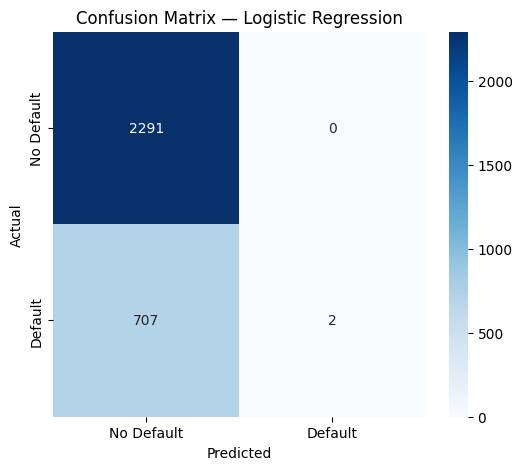

In [12]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Observation
The confusion matrix shows 2,291 true negatives and 707 false negatives — the model predicted No Default for every single borrower, catching zero actual defaults.

### Insight
76% accuracy here is misleading — the model simply learned to always predict the majority class. In lending, missing every defaulter is far more costly than the accuracy number suggests. This confirms that numerical features alone cannot build a usable risk model without adding product-level variables.

## Statistical Summary

| Test | Variable | Result | Business Implication |
|------|----------|--------|---------------------|
| T-Test | Credit Score | Not significant (p=0.735) | Must not be used as primary screening criterion |
| T-Test | DTI | Highly significant (p=0.000) | Valid screening variable |
| T-Test | LTV | Highly significant (p=0.000) | Strongest numerical predictor |
| T-Test | Income | Highly significant (p=0.000) | Repayment capacity matters more than credit score |
| Chi-Square | credit_score_bucket | Not significant (p=0.722) | Credit score bands have no association with default |
| Chi-Square | lump_sum_payment | Highly significant (χ²=498.5) | Strongest categorical risk signal |
| Chi-Square | ltv_risk_bucket | Highly significant (χ²=451.9) | LTV bucketing is statistically valid |
| Chi-Square | neg_ammortization | Highly significant (χ²=363.1) | Product-level restriction warranted |
| Point Biserial | LTV | 0.0976 (highest) | Most predictive numerical variable |
| Point Biserial | Credit Score | -0.0028 (near zero) | Statistically confirms zero predictive power |
| Scenario | LTV Cap Policy | 23.72% → 20.73% | Capping Very High LTV reduces default rate by 3 points and saves ₹4,28,506,000 in exposure |
| DTI Threshold | DTI=43% | Difference of -2.2% | Industry threshold ineffective in this portfolio |
| Logistic Regression | ROC-AUC | 0.596 — near random | Numerical metrics alone cannot predict default |
| Logistic Regression | LTV coefficient | 0.2239 (highest) | Confirms LTV as primary risk driver |